# <div align="center"><b> Detección del picudo rojo mediante YoloV11 </b></div>

<div align="right">

<!-- [![Binder](http://mybinder.org/badge.svg)](https://mybinder.org/) -->
[![nbviewer](https://img.shields.io/badge/render-nbviewer-orange?logo=Jupyter)](https://nbviewer.org)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://githubtocolab.com)

</div>

* * *

<style>
/* Limitar la altura de las celdas de salida en html */
.jp-OutputArea.jp-Cell-outputArea {
    max-height: 500px;
}
</style>

🛻 <em><font color='MediumSeaGreen'>  Instalaciones: </font></em> 🛻

Este notebook utiliza [Poetry](https://python-poetry.org/) para la gestión de dependencias.
Primero instala Poetry siguiendo las instrucciones de su [documentación oficial](https://python-poetry.org/docs/#installation).
Luego ejecuta el siguiente comando para instalar las dependencias necesarias y activar el entorno virtual:

- Bash:
```bash
poetry install
eval $(poetry env activate)
```

- PowerShell:
```powershell
poetry install
Invoke-Expression (poetry env activate)
```

<!-- Descargar archivos adicionales:
!gdown https://drive.google.com/drive/folders/1UBZ8PEbtmiWMGkULu7GAt3VhUpeTy9l7?usp=sharing --folder -->

In [1]:
# Chequear versión de CUDA
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Oct_30_01:18:48_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.6, V12.6.85
Build cuda_12.6.r12.6/compiler.35059454_0


In [2]:
# Chequear más datos sobre la GPU
!nvidia-smi

Tue Oct 21 10:46:25 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.36                 Driver Version: 566.36         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
|  0%   37C    P8              5W /  320W |    5028MiB /  16376MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

✋ <em><font color='DodgerBlue'>Importaciones:</font></em> ✋

In [3]:
# Recarga automática de módulos en Jupyter Notebook
%reload_ext autoreload
%autoreload 2

In [4]:
# Dependencias del sistema
from IPython.display import display
import sys, json, requests, os, shutil, yaml, random
from pathlib import Path
from pprint import pprint

# Dependencias locales
from modulo_ia.config import settings as CONFIG
from modulo_ia import dataset as dataset_processor
from modulo_ia import features as features_processor
from modulo_ia.utils import gpu as gpu_utils, yolo_utils
from modulo_ia.core.modeling.predict import DetectionModelPredictor
from modulo_ia.utils.types import DatasetFormat
from modulo_ia.visualizations import TrainingVisualizer

# Dependencias propias
from modulo_utilidades.labeling import procesador_anotaciones_coco_dataset
from modulo_utilidades.s3_comunication import procesador_s3
from modulo_utilidades.labeling import visualizador_coco_dataset
from modulo_utilidades.labeling import procesador_anotaciones_mongodb
from modulo_utilidades.labeling import procesador_geojson_kml
from modulo_utilidades.utils.types import ImageMetadata

# Dependencias de terceros
from loguru import logger as LOGGER
# os.environ["ALBUMENTATIONS_DISABLE"] = "1" # Deshabilita Albumentations por defecto.
import ultralytics
from ultralytics import YOLO, settings
from ultralytics.data.utils import visualize_image_annotations
import torch
import mlflow
import cv2
import PIL
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
# Fix for FiftyOne plugin operators
os.environ["FIFTYONE_PLUGINS_DIR"] = "E:\\Documentos\\Git Repositories\\uba-ceia-proy-final\\ceia-proyecto-final\\modulo-IA\\.venv\\Lib\\site-packages\\plugins\\operators"
import fiftyone as fo
fo.config.plugins_dir = "E:\\Documentos\\Git Repositories\\uba-ceia-proy-final\\ceia-proyecto-final\\modulo-IA\\.venv\\Lib\\site-packages\\plugins\\operators"

2025-10-21 10:46:25.372 | WARNING  | modulo_ia.config:<module>:17 - Using .env file at E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\.env for configuration.
E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\modulo_ia\config.py:68: UserWarning: Field name "schema" in "FiftyoneConfig" shadows an attribute in parent "BaseModel"
  class FiftyoneConfig(BaseModel):
E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\modulo_ia\config.py:79: UserWarning: Field name "schema" in "MLFlowConfig" shadows an attribute in parent "BaseModel"
  class MLFlowConfig(BaseModel):
2025-10-21 10:46:25.379 | DEBUG    | modulo_ia.config:<module>:113 - Settings loaded: {
  "environment": "dev",
  "seed": 42,
  "folders": {
    "data_folder": "E:\\Documentos\\Git Repositories\\uba-ceia-proy-final\\ceia-proyecto-final\\modulo-IA\\data",
    "models_folder": "E:\\Documentos\\Git Repositories\\uba-ceia-proy-final\\ceia-pro

🔧 <em><font color='tomato'>Configuraciones:</font></em> 🔧


In [5]:
# CONFIGURACIONES GENERALES
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"  # Establece el dispositivo.
LOGGER.remove()
LOGGER.add(sys.stderr, level="INFO")
PIL.Image.MAX_IMAGE_PIXELS = None  # Evita errores con imágenes muy grandes

# COMPORTAMIENTO DEL NOTEBOOK
SHOULD_PROCESS_DATASET = False  # Descarga el dataset completo
SHOULD_TRAIN = False  # Entrenamiento
SHOULD_SEARCH_HYPERPARAMETERS = False  # Búsqueda de hiperparámetros
# CARPETAS
RAW_DATA_FOLDER = CONFIG.folders.raw_data_folder
EXTERNAL_DATA_FOLDER = CONFIG.folders.external_data_folder
INTERIM_DATA_FOLDER = CONFIG.folders.interim_data_folder
PROCESSED_DATA_FOLDER = CONFIG.folders.processed_data_folder
DATA_FOLDER = CONFIG.folders.data_folder
DOWNLOAD_COCO_ANNOTATIONS_FOLDER = Path("downloads") / "coco_annotations"  # Carpeta para descargar anotaciones COCO
DOWNLOAD_PREDICTION_FOLDER = Path("downloads") / "predictions"  # Carpeta para descargar parches de prueba
DOWNLOAD_JGW_DATA_FOLDER = Path("downloads") / "jgw_data"  # Carpeta para descargar datos JGW
DOWNLOAD_GEOJSON_FOLDER = Path("downloads") / "geojson_annotations"  # Carpeta para descargar geojsons
DOWNLOAD_KML_FOLDER = Path("downloads") / "kml_annotations"  # Carpeta para descargar kmls
MODEL_FOLDER = CONFIG.folders.models_folder
RPW_DETECTION_YOLOV11_FOLDER = CONFIG.folders.rpw_detection_yolov11_folder

# CONFIGURACIONES DE ENTRENAMIENTO
BATCH_SIZE = 16  # 16 -> Yolo11x | # 64 -> Yolo11n
N_EPOCHS = 300  # Número de épocas
VERBOSE = True  # Muestra época a época la evolución
IMG_SIZE = 640  # Tamaño de la imagen
RANDOM_SEED = CONFIG.seed  # Semilla para la aleatoriedad
CROP_THRESHOLD = 0.2  # Umbral de inclusión de etiquetas en recortes
CROP_OVERLAP = 250  # Solapamiento entre recortes
BACKGROUND_PERCENTAGE = 0.1  # Porcentaje de fondo en el dataset balanceado
FREEZE_LAYERS = 10  # Número de capas a congelar
EARLY_STOPPING = 50  # Paciencia para el early stopping

# DATA AUGMENTATIONS
# Opciones: train_no_aumentations.yaml | train_custom1_aumentations.yaml | train_custom2_aumentations.yaml | train_custom3_aumentations.yaml
AUMENTATIONS_CONFIG_FILE_NAME = "train_custom4_aumentations"
AUMENTATIONS_CONFIG_FILE_PATH = RPW_DETECTION_YOLOV11_FOLDER / f"{AUMENTATIONS_CONFIG_FILE_NAME}.yaml"
CUSTOM_TRANSFORMS = [AUMENTATIONS_CONFIG_FILE_NAME]
UNDER_SAMPLING = False # Entrenar con menos datos.
UNDER_SAMPLING_TARGET_SIZE = 5000  # Tamaño objetivo del dataset tras el undersampling

# TAREA
TASK_NAME = "rpw_detection"
CLASS_NAMES = {
    0: "palmera-sana",
    1: "palmera-infectada",
    2: "palmera-muerta",
}
COLOR_MAP = {
    "palmera-sana": (0, 255, 0),  # Verde
    "palmera-infectada": (255, 255, 0),  # Amarillo
    "palmera-muerta": (255, 0, 0),  # Rojo
}
CATEGORIES = [{"id": id, "name": name, "supercategory": ""} for id, name in CLASS_NAMES.items()]

# MODELO
MODEL_NAME = "yolo11x"
# Opciones: f"{MODEL_NAME}.pt" | Ruta al checkpoint personalizado (MODEL_FOLDER / "coco_palm_dataset_v1.0_palm_detection_yolo11x_640_b7218a073a3942339689b2e7f4e0b543.pt")
MODEL_CHECKPOINT = MODEL_FOLDER / "palm_detection_yolo11x_640_a3a50bd4646e4044bed83f02f8bb03f4.pt"

# DATOS DEL DATASET
DATASET_NAME = CONFIG.names.palm_dataset_name
RAW_DATASET_VERSION = CONFIG.raw_dataset_versions.v11
RAW_DATASET_IDENTIFIER = f"{DATASET_NAME}_{RAW_DATASET_VERSION}"
PROCESSED_DATASET_VERSION = CONFIG.processed_dataset_versions.v111
PROCESSED_DATASET_IDENTIFIER = f"{DATASET_NAME}_{PROCESSED_DATASET_VERSION}"
DATASET_FINAL_FORMAT = CONFIG.processed_dataset_format.yolo  # Formato final del dataset procesado

# RUTAS Y NOMBRES
DATASET_RAW_NAME = RAW_DATASET_IDENTIFIER
DATASET_RAW_PATH = RAW_DATA_FOLDER / DATASET_RAW_NAME
DATASET_INTERIM_NAME = RAW_DATASET_IDENTIFIER
DATASET_INTERIM_PATH = INTERIM_DATA_FOLDER / DATASET_INTERIM_NAME
DATASET_INTERIM_STEP_PATH = INTERIM_DATA_FOLDER / f"{DATASET_INTERIM_NAME}_step"
DATASET_INTERIM_STEP_NAME = f"{DATASET_INTERIM_NAME}_step"
DATASET_PROCESSED_NAME = f"{PROCESSED_DATASET_IDENTIFIER}_{TASK_NAME}_{DATASET_FINAL_FORMAT}"
DATASET_PROCESSED_PATH = PROCESSED_DATA_FOLDER / DATASET_PROCESSED_NAME
EXPERIMENT_NAME = f"{TASK_NAME}_{MODEL_NAME.replace('/', '_')}_{IMG_SIZE}"
EXPERIMENT_FULL_TRAINING_NAME = f"{EXPERIMENT_NAME}_full_training"
EXPERIMENT_FULL_TRAINING_PATH = RPW_DETECTION_YOLOV11_FOLDER / EXPERIMENT_FULL_TRAINING_NAME
EXPERIMENT_HYPERPARAMETER_SEARCH_FULL_TRAINING_PATH = (
    RPW_DETECTION_YOLOV11_FOLDER / f"{EXPERIMENT_FULL_TRAINING_NAME}_hyperparameter_search"
)
EXPERIMENT_FREEZE_TRAINING_NAME = f"{EXPERIMENT_NAME}_freeze_learning"
EXPERIMENT_FREEZE_TRAINING_PATH = RPW_DETECTION_YOLOV11_FOLDER / EXPERIMENT_FREEZE_TRAINING_NAME
EXPERIMENT_HYPERPARAMETER_SEARCH_FREEZE_TRAINING_PATH = (
    RPW_DETECTION_YOLOV11_FOLDER / f"{EXPERIMENT_FREEZE_TRAINING_NAME}_hyperparameter_search"
)
BEST_MODEL_VAL_RESULTS_PATH = Path("bbest_model_val_results")

# RESULTADOS
MODELS_PERFORMANCE_RESULTS = []

# PREDICCINES
NMS_IOU_THRESHOLD = 0.1
NMM_IOU_THRESHOLD = 0.1
CONFIDENCE = 0.5
MIN_RATIO = 0.7
CONTAINERMENT_THRESHOLD = 0.8
OVERLAP_RATIO_WH = (0.1, 0.1)

# MLFLOW
MLFLOW_URL = CONFIG.mlflow.tracking_uri
MLFLOW_TRACKING_USERNAME = CONFIG.mlflow.tracking_username
MLFLOW_TRACKING_PASSWORD = CONFIG.mlflow.tracking_password
os.environ["MLFLOW_TRACKING_URI"] = MLFLOW_URL  # Configura la URI de seguimiento de MLflow.
os.environ["MLFLOW_TRACKING_USERNAME"] = MLFLOW_TRACKING_USERNAME  # Configura el nombre de usuario para MLflow.
os.environ["MLFLOW_TRACKING_PASSWORD"] = MLFLOW_TRACKING_PASSWORD  # Configura la contraseña para MLflow.
os.environ["MLFLOW_TAGS"] = '{"model_family": "rpw_detection"}'  # Configura las etiquetas del experimento de MLflow.
settings.update({"mlflow": True})  # Habilita el uso de MLflow en ultralytics

# COMPROBACIONES
ultralytics.checks()  # Verifica la instalación de ultralytics
LOGGER.info(f"Dispositivo actual: {DEVICE}")

Ultralytics 8.3.218  Python-3.13.3 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
Setup complete  (20 CPUs, 127.9 GB RAM, 1042.5/1862.9 GB disk)


2025-10-21 10:46:30.784 | INFO     | __main__:<module>:117 - Dispositivo actual: cuda


<div align="center">✨Datos del proyecto:✨</div>

<p></p>

<div align="center">

| **Subtitulo**   | Detección de rpw - YoloV11                                                                                                        |
| --------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| **Descrpción**  | <small>Notebook de detección del picudo rojo utilizando YoloV11</small>                                                                    |

</div>

## Chequeo de conexiones

In [6]:
# Chequeo de conexión a MLflow
LOGGER.info(f"Conectando a MLflow en {MLFLOW_URL}...")
try:
    response = requests.get(MLFLOW_URL)
    response.raise_for_status()  # Verifica si la solicitud fue exitosa.
    LOGGER.success("Conexión a MLflow establecida correctamente.")
except Exception as e:
    LOGGER.error(f"Error al conectar con MLflow. Tienes levantado el servidor de MLflow?")
    raise SystemExit(f"Error al conectar con MLflow: {e}")

# Chequeo de conexión a MinIO
LOGGER.info("Chequeando conexión a MinIO...")
procesador_s3.test_connection()

# Chequeo de conexión a MongoDB
LOGGER.info("Chequeando conexión a MongoDB...")
procesador_anotaciones_mongodb.test_connection()
LOGGER.success("Conexión a MongoDB verificada correctamente.")

2025-10-21 10:46:30.860 | INFO     | __main__:<module>:2 - Conectando a MLflow en http://localhost:5000...
2025-10-21 10:46:30.866 | SUCCESS  | __main__:<module>:6 - Conexión a MLflow establecida correctamente.
2025-10-21 10:46:30.867 | INFO     | __main__:<module>:12 - Chequeando conexión a MinIO...
2025-10-21 10:46:30.873 | SUCCESS  | modulo_utilidades.s3_comunication.procesador_s3:test_connection:39 - Conexión exitosa a S3 y acceso al bucket 'picudo-rojo-bucket' verificado.
2025-10-21 10:46:30.874 | INFO     | __main__:<module>:16 - Chequeando conexión a MongoDB...
2025-10-21 10:46:30.883 | SUCCESS  | modulo_utilidades.labeling.procesador_anotaciones_mongodb:test_connection:39 - Conexión a la base de datos MongoDB exitosa.
2025-10-21 10:46:30.883 | SUCCESS  | __main__:<module>:18 - Conexión a MongoDB verificada correctamente.


## Raw dataset

In [7]:
if SHOULD_PROCESS_DATASET:
    if DATASET_RAW_PATH.exists():
        LOGGER.info("Dataset ya descargado. Procesando dataset...")

        dataset_metrics = dataset_processor.get_dataset_metrics(
            dataset_path=DATASET_RAW_PATH, dataset_name=DATASET_RAW_NAME, dataset_format=dataset_processor.DatasetFormat.COCO
        )
        dataset_stats = dataset_processor.get_dataset_stats(
            dataset_path=DATASET_RAW_PATH, dataset_name=DATASET_RAW_NAME, dataset_format=dataset_processor.DatasetFormat.COCO
        )
        LOGGER.info(f"Metricas del dataset:\n {json.dumps(dataset_metrics, indent=2)}")
        LOGGER.info(f"Estadísticas del dataset:\n {json.dumps(dataset_stats, indent=2)}")
    else:
        LOGGER.error(f"El dataset no fue encontrado en {DATASET_RAW_PATH}. Tienes que descargarlo previamente.")
        sys.exit(1)

## Procesamiento del dataset

### Procesamiento de labels

Mostramos las clases originales:

In [8]:
with open(DATASET_RAW_PATH / "labels.json", "r") as f:
    labels_data = json.load(f)
LOGGER.info(f"Clases originales:\n {json.dumps(labels_data['categories'], indent=2)}")

2025-10-21 10:46:31.515 | INFO     | __main__:<module>:3 - Clases originales:
 [
  {
    "id": 0,
    "name": "palmera-sana",
    "supercategory": ""
  },
  {
    "id": 1,
    "name": "palmera-infectada",
    "supercategory": ""
  },
  {
    "id": 2,
    "name": "palmera-muerta",
    "supercategory": ""
  },
  {
    "id": 3,
    "name": "palmera-exterminada",
    "supercategory": ""
  }
]


In [9]:
CUSTOM_TRANSFORMS.append("delete_label: palmera-exterminada")  # Agrega la transformación de eliminación de etiqueta
if SHOULD_PROCESS_DATASET:
    LOGGER.debug("Copiando dataset...")
    # Copiamos el dataset a la carpeta de datos
    shutil.copytree(DATASET_RAW_PATH, DATASET_INTERIM_PATH, dirs_exist_ok=True)

    json_folder = DATASET_INTERIM_PATH
    coco_anotations = procesador_anotaciones_coco_dataset.load_annotations_from_path(json_folder / "labels.json")

    LOGGER.info("Eliminando etiqueta 'palmera-exterminada'...")    
    coco_anotations = procesador_anotaciones_coco_dataset.delete_label(coco_anotations, "palmera-exterminada")

    with open(json_folder / "labels.json", "w") as f:
        json.dump(coco_anotations, f, indent=4)
        LOGGER.info(f"Se copió el dataset y se guardó el archivo de etiquetas en {json_folder / 'labels.json'}")

    LOGGER.info(f"Nuevas categorías:\n {json.dumps(coco_anotations['categories'], indent=2)}")

### Convertir dataset a formato YOLO
<small><em>https://docs.ultralytics.com/reference/cfg/__init__/</em></small>

In [10]:
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Convirtiendo el dataset a formato de modelo...")
    dataset_processor.convert_dataset_to_model_format(dataset_path=DATASET_INTERIM_PATH, output_dir=DATASET_INTERIM_STEP_PATH, clean=True)

Ejemplo con views splits:

```python
for split in splits:
    split_view = dataset_or_view.match_tags(split)
    split_view.export(
        export_dir=export_dir,
        dataset_type=fo.types.YOLOv5Dataset,
        label_field=label_field,
        split=split,
        classes=classes,
    )
```

### Recortar el dataset en imágenes pequeñas

In [11]:
CUSTOM_TRANSFORMS.append(f"crop threshold: {CROP_THRESHOLD}")  # Agrega la transformación de recorte
CUSTOM_TRANSFORMS.append(f"crop overlap: {CROP_OVERLAP}")  # Agrega la transformación de recorte
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Cortando el dataset para entrenamiento...")
    features_processor.crop_dataset(
        dataset_path=DATASET_INTERIM_STEP_PATH, crop_size=IMG_SIZE, overlap=CROP_OVERLAP, threshold=CROP_THRESHOLD
    )

    dataset_metrics = dataset_processor.get_dataset_metrics(
        dataset_path=DATASET_INTERIM_STEP_PATH,
        dataset_name=DATASET_INTERIM_STEP_NAME,
        dataset_format=DatasetFormat.YOLO,
    )
    LOGGER.info(f"Metricas del dataset:\n {json.dumps(dataset_metrics, indent=2)}")

### Balancear el dataset

In [12]:
CUSTOM_TRANSFORMS.append(f"background percentage: {BACKGROUND_PERCENTAGE}")
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Balanceando el dataset...")
    features_processor.balance_dataset_v1(
        dataset_path=DATASET_INTERIM_STEP_PATH,
        output_path=DATASET_INTERIM_STEP_PATH,
        all_classes=True,
        background_percentage=BACKGROUND_PERCENTAGE,
        export_categories=CATEGORIES,
    )

    dataset_metrics = dataset_processor.get_dataset_metrics(
        dataset_path=DATASET_INTERIM_STEP_PATH,
        dataset_name=DATASET_INTERIM_STEP_NAME,
        dataset_format=DatasetFormat.YOLO,
    )
    LOGGER.info(f"Metricas del dataset:\n {json.dumps(dataset_metrics, indent=2)}")

### Under sampling

In [13]:
if SHOULD_PROCESS_DATASET:
    if UNDER_SAMPLING:
        LOGGER.info(f"Aplicando under sampling al dataset para reducirlo a {UNDER_SAMPLING_TARGET_SIZE} imágenes...")
        features_processor.under_sample_dataset(
            dataset_path=DATASET_INTERIM_STEP_PATH,
            output_path=DATASET_INTERIM_STEP_PATH,
            export_categories=CATEGORIES,
            target_size=UNDER_SAMPLING_TARGET_SIZE,
        )

    dataset_metrics = dataset_processor.get_dataset_metrics(
        dataset_path=DATASET_INTERIM_STEP_PATH,
        dataset_name=DATASET_INTERIM_STEP_NAME,
        dataset_format=DatasetFormat.YOLO,
    )
    LOGGER.info(f"Metricas del dataset final:\n {json.dumps(dataset_metrics, indent=2)}")

### Split del dataset

In [14]:
CUSTOM_TRANSFORMS.append("split: 0.8, 0.1, 0.1")  # Agrega la transformación de split
if SHOULD_PROCESS_DATASET:
    LOGGER.info("Split del dataset...")
    dataset_processor.split_dataset(dataset_path=DATASET_INTERIM_STEP_PATH, output_dir=DATASET_PROCESSED_PATH, clean=True, ratios=(0.8, 0.1, 0.1))

### Validaciones del dataset

#### Existencia del archivo dataset.yaml

In [15]:
dataset_yaml_path = DATASET_PROCESSED_PATH / "dataset.yaml"
if not dataset_yaml_path.exists():
    raise FileNotFoundError(f"El archivo {dataset_yaml_path} no existe. Asegúrate de que el dataset se haya procesado correctamente.")
LOGGER.success(f"Archivo dataset.yaml encontrado en {dataset_yaml_path}")

2025-10-21 10:46:32.034 | SUCCESS  | __main__:<module>:4 - Archivo dataset.yaml encontrado en E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1.1_rpw_detection_yolo\dataset.yaml


#### Congruencia de las clases

In [16]:
with open(dataset_yaml_path, "r") as f:
    dataset_yaml = yaml.safe_load(f)
    LOGGER.debug(f"Dataset YAML cargado: {dataset_yaml}")

DATASET_YAML_CLASS_NAMES = dataset_yaml["names"]
if set(DATASET_YAML_CLASS_NAMES.values()) != set(CLASS_NAMES.values()):
    raise ValueError(
        f"Las clases del dataset YAML {DATASET_YAML_CLASS_NAMES} no coinciden con las esperadas {CLASS_NAMES.values()}."
    )

LOGGER.success("Validaciones de clases realizadas correctamente.")

2025-10-21 10:46:32.112 | SUCCESS  | __main__:<module>:11 - Validaciones de clases realizadas correctamente.


### Metricas del dataset procesado

In [17]:
dataset_metrics = dataset_processor.get_dataset_metrics(
    dataset_path=DATASET_PROCESSED_PATH,
    dataset_name=DATASET_PROCESSED_NAME,
    dataset_format=dataset_processor.DatasetFormat.YOLO,
)
dataset_metrics_json = json.dumps(dataset_metrics, indent=2)
LOGGER.info(f"Metricas del dataset:\n {dataset_metrics_json}")

You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
 100% |█████████████████| 766/766 [4.1s elapsed, 0s remaining, 189.9 samples/s]      
 100% |███████████████████| 96/96 [543.7ms elapsed, 0s remaining, 176.6 samples/s]      
 100% |███████████████████| 96/96 [486.2ms elapsed, 0s remaining, 197.5 samples/s]      


2025-10-21 10:46:38.120 | WARNING  | modulo_ia.dataset:get_dataset_metrics:442 - Advertencia: no se pudo agregar el split "full" al dataset. Error: Dataset YAML 'E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1.1_rpw_detection_yolo\dataset.yaml' does not contain split 'full'
2025-10-21 10:46:38.142 | INFO     | __main__:<module>:7 - Metricas del dataset:
 {
  "train_count": 766,
  "train_images_with_detections": 700,
  "train_images_without_detections": 66,
  "train_class_count": {
    "palmera-muerta": 389,
    "palmera-infectada": 422,
    "palmera-sana": 672
  },
  "val_count": 96,
  "val_images_with_detections": 86,
  "val_images_without_detections": 10,
  "val_class_count": {
    "palmera-infectada": 53,
    "palmera-muerta": 43,
    "palmera-sana": 67
  },
  "test_count": 96,
  "test_images_with_detections": 85,
  "test_images_without_detections": 11,
  "test_class_count": {
    "palmera-sana": 76,
    "palmera

### Visualización

#### Observamos el dataset

> 📝 <em><font color='Gray'>Nota:</font></em> Si hay problema de versiones con `FiftyOne`, borrar la base de datos del mismo que se encuentra en: `C:\Users\<usuario>\.fiftyone\`</em>

In [18]:
if SHOULD_PROCESS_DATASET:
    dataset = fo.Dataset(name=DATASET_PROCESSED_NAME, overwrite=True)
    for split in ["train", "val", "test", "full"]:
        try:
            dataset.add_dir(
                dataset_dir=DATASET_PROCESSED_PATH, dataset_type=fo.types.YOLOv5Dataset, split=split, tags=[split]
            )
        except Exception as e:
            LOGGER.warning(f'Advertencia: no se pudo agregar el split "{split}" al dataset. Error: {e}')
            pass
    try:
        session = fo.launch_app(dataset)
        session.freeze()
    except Exception as e:
        LOGGER.error(f"No se pudo iniciar FiftyOne. Error: {e}")
        pass

Accedemos a la visualización: <a>http://localhost:5151</a>

#### Observamos algunas imágenes

2025-10-21 10:46:38.289 | INFO     | __main__:<module>:14 - Archivo de texto seleccionado para visualización: E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1.1_rpw_detection_yolo\labels\train\RGB_MVD_2024_J-29-C-1-M-5_patch_22_crop_18.txt


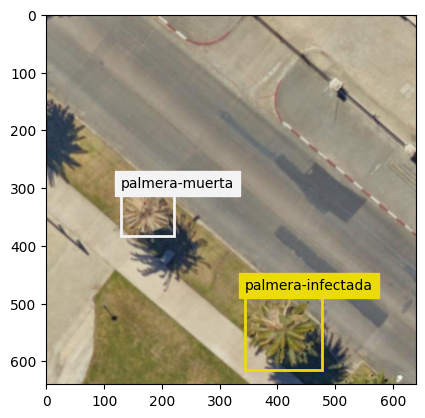

In [19]:
train_image_folder = DATASET_PROCESSED_PATH / "images" / "train"
train_annotations_folder = DATASET_PROCESSED_PATH / "labels" / "train"
# Select one random image from the train folder
if not train_image_folder.exists() or not train_annotations_folder.exists():
    raise FileNotFoundError(
        f"Las carpetas de entrenamiento no existen: {train_image_folder} o {train_annotations_folder}. Asegúrate de que el dataset se haya procesado correctamente."
    )
text_files = list(train_annotations_folder.glob("*.txt"))
if not text_files:
    raise FileNotFoundError(
        f"No se encontraron archivos de texto en {train_annotations_folder}. Asegúrate de que el dataset se haya procesado correctamente."
    )
text_path = random.choice(text_files)
LOGGER.info(f"Archivo de texto seleccionado para visualización: {text_path}")

image_path = train_image_folder / text_path.with_suffix(".jpg").name
if not image_path.exists():
    raise FileNotFoundError(
        f"La imagen {image_path} no existe. Asegúrate de que el dataset se haya procesado correctamente."
    )

category_map = {cat["id"]: cat["name"] for cat in CATEGORIES}

visualize_image_annotations(image_path, text_path, category_map)

#### Observamos el aumento de datos

train: Fast image access  (ping: 0.10.1 ms, read: 8.11.9 MB/s, size: 148.4 KB)
train: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1.1_rpw_detection_yolo\labels\train.cache... 766 images, 66 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 766/766 1.1Mit/s 0.0s0s


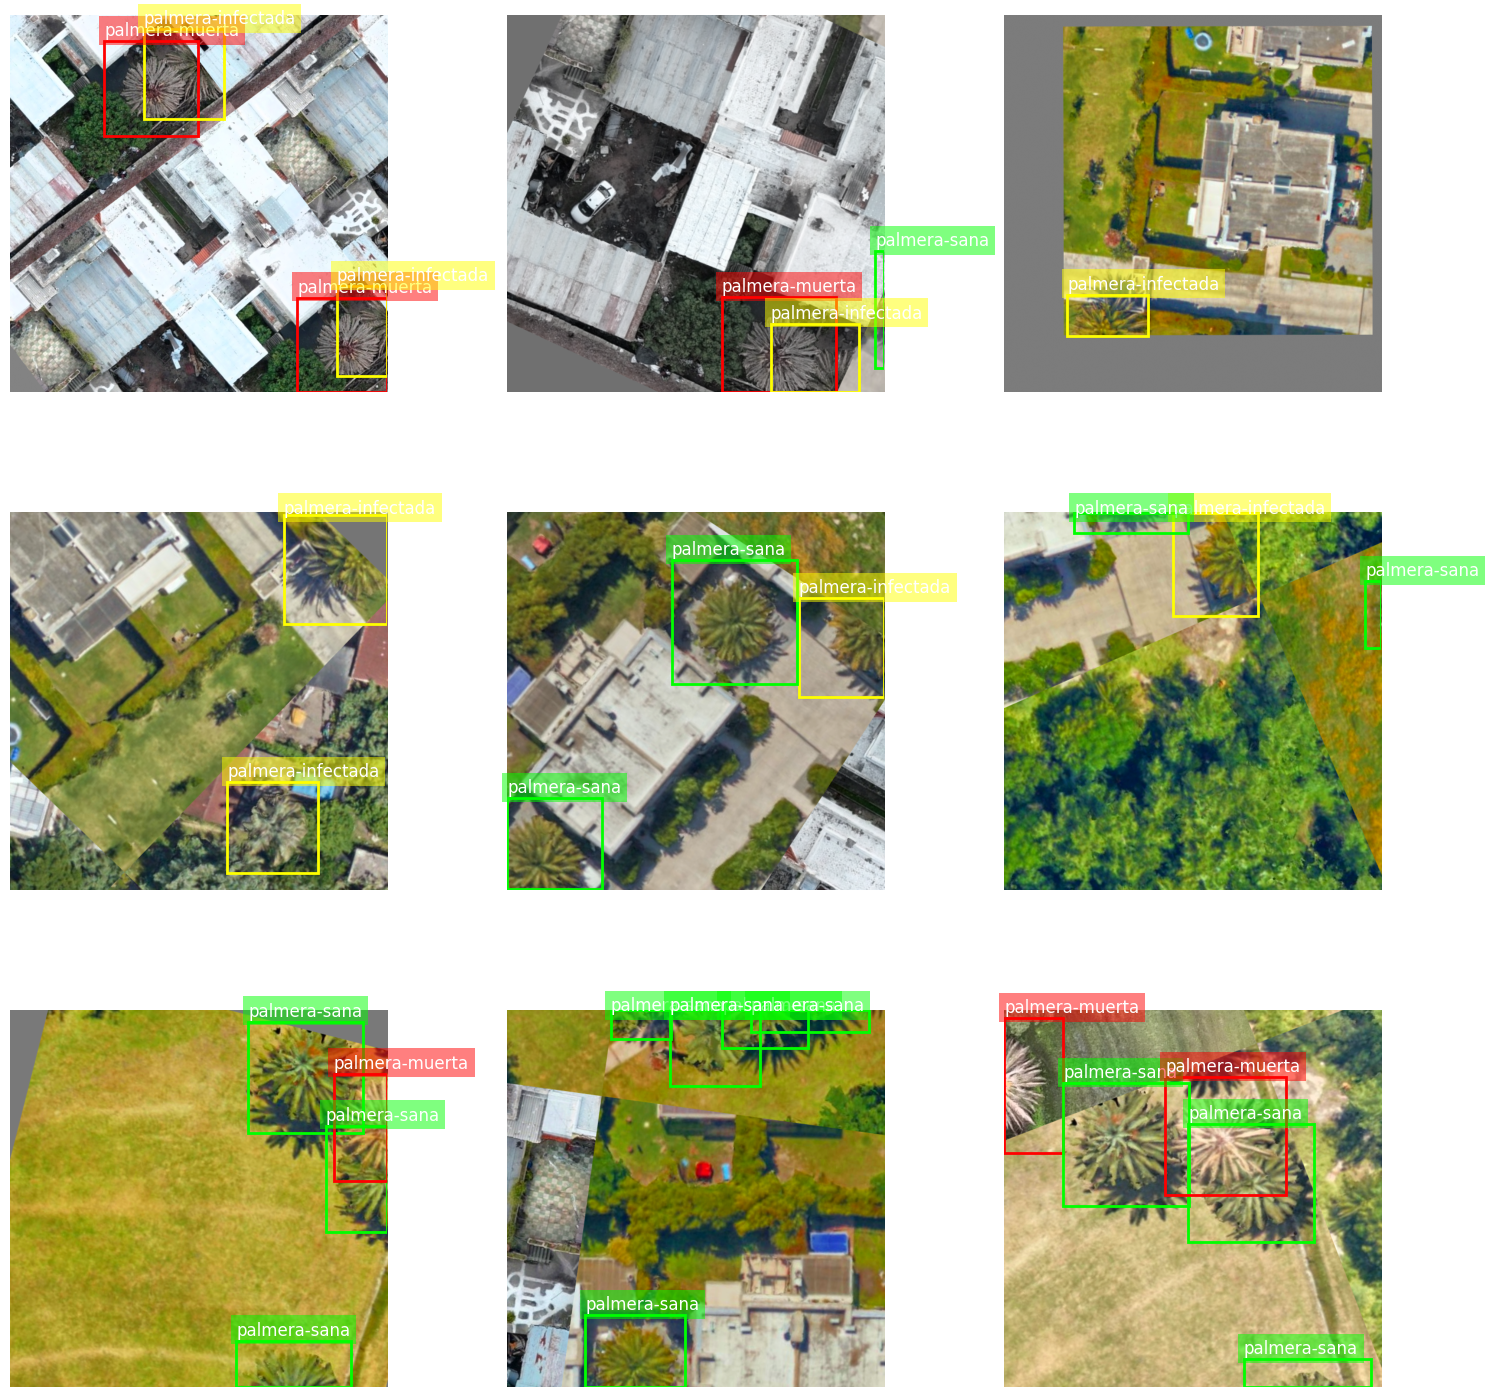

In [20]:
yolo_training_dataloader = yolo_utils.get_yolo_training_dataloader(
    cfg_path=AUMENTATIONS_CONFIG_FILE_PATH,
    cfg_data=DATASET_PROCESSED_PATH / "dataset.yaml",
    cfg_imgsz=IMG_SIZE,
    cfg_batch=9,
    dataset_path=DATASET_PROCESSED_PATH / "images" / "train",
    shuffle=True,
)
yolo_utils.plot_yolo_augmentations(yolo_training_dataloader, CLASS_NAMES, color_map=COLOR_MAP, max_batches=1)

## Entrenamientos de modelos

$\rightarrow$ Entrenamiento el modelo:
- <small>https://docs.ultralytics.com/yolov5/tutorials/tips_for_best_training_results/#advanced-optimization-techniques</small>
- <small>https://docs.ultralytics.com/guides/yolo-data-augmentation/#introduction</small>

$\rightarrow$ Configuraciones de entrenamiento:
- <small><em>https://docs.ultralytics.com/modes/train/#train-settings</em></small>

$\rightarrow$ Configuraciones de validación:
- <small><em>https://docs.ultralytics.com/es/modes/val/#usage-examples</em></small>

$\rightarrow$ Transfer Learning:
- <small>https://www.ultralytics.com/glossary/transfer-learning</small>
- <small>https://docs.ultralytics.com/yolov5/tutorials/transfer_learning_with_frozen_layers/#how-layer-freezing-works</small>
- <small>https://community.ultralytics.com/t/guidance-on-freezing-layers-for-yolov8x-seg-transfer-learning/189</small>

$\rightarrow$ Batch size:
> 📝 <em><font color='Gray'>Nota:</font></em> $\text{Max batch size} = \frac{\text{Available GPU memory (bytes)}}{4 \times (\text{Size of tensors} + \text{Trainable parameters})}$

$\rightarrow$ Hiperparámetros:
- <small><em>https://docs.ultralytics.com/guides/hyperparameter-tuning/</em></small>
- <small><em>https://docs.ultralytics.com/integrations/ray-tune/</em></small>

$\rightarrow$ Ejemplo search grid:
Ejemplo de uso de grid search para hiperparámetros:

```python
from ultralytics import YOLO
import itertools

param_grid = {
    'imgsz': [240, 256, 416],
    'batch': [16, 32, 64],
    'momentum': [0.937, 0.8],
    'optimizer': ['adam', 'adamW'],
}

# Generate combinations
param_combinations = list(itertools.product(*param_grid.values()))

best_map = 0
best_params = {}
for combination in param_combinations:
    params = dict(zip(param_grid.keys(), combination))
    model = YOLO('yolov8n.pt')
    results = model.train(data='coco128.yaml', epochs=50, **params)
    if results['val/mAP_0.5'] > best_map:
        best_map = results['val/mAP_0.5']
        best_params = params

print("Best mAP: {:.4f} with Parameters: {}".format(best_map, best_params))
```

### Datos del modelo base

Checkpoint:

In [21]:
print(f"Checkpoint del modelo base: {MODEL_CHECKPOINT}")
model = YOLO(MODEL_CHECKPOINT)

Checkpoint del modelo base: E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\models\palm_detection_yolo11x_640_a3a50bd4646e4044bed83f02f8bb03f4.pt


Resumen de arquitectura:

In [22]:
for name, param in model.named_parameters():
    print(name)

model.model.0.conv.weight
model.model.0.bn.weight
model.model.0.bn.bias
model.model.1.conv.weight
model.model.1.bn.weight
model.model.1.bn.bias
model.model.2.cv1.conv.weight
model.model.2.cv1.bn.weight
model.model.2.cv1.bn.bias
model.model.2.cv2.conv.weight
model.model.2.cv2.bn.weight
model.model.2.cv2.bn.bias
model.model.2.m.0.cv1.conv.weight
model.model.2.m.0.cv1.bn.weight
model.model.2.m.0.cv1.bn.bias
model.model.2.m.0.cv2.conv.weight
model.model.2.m.0.cv2.bn.weight
model.model.2.m.0.cv2.bn.bias
model.model.2.m.0.cv3.conv.weight
model.model.2.m.0.cv3.bn.weight
model.model.2.m.0.cv3.bn.bias
model.model.2.m.0.m.0.cv1.conv.weight
model.model.2.m.0.m.0.cv1.bn.weight
model.model.2.m.0.m.0.cv1.bn.bias
model.model.2.m.0.m.0.cv2.conv.weight
model.model.2.m.0.m.0.cv2.bn.weight
model.model.2.m.0.m.0.cv2.bn.bias
model.model.2.m.0.m.1.cv1.conv.weight
model.model.2.m.0.m.1.cv1.bn.weight
model.model.2.m.0.m.1.cv1.bn.bias
model.model.2.m.0.m.1.cv2.conv.weight
model.model.2.m.0.m.1.cv2.bn.weight
mo

Arquitectura del modelo base:

In [23]:
print(model)

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(96, 192, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(192, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(192, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(192, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(384, 384, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(384, eps=0.001, momentum=0.03, affine=True, track_

### Entrenamiento del modelo - Full training

In [24]:
model = YOLO(MODEL_CHECKPOINT)

#### Busqueda de hiperparámetros

In [25]:
space_search = {
    "lr0": [0.01, 0.001, 0.0001],  # Learning rate
    "lrf": [0.1, 0.01],  # Learning rate final como una fracción de lr0
    "box": [7.5, 4.0, 0.5],  # Box loss gain
    "cls": [7.5, 4.0, 0.5],  # Class loss gain
    "dfl": [7.5, 4.0, 1.5, 0.5],  # DFL loss gain
}

In [26]:
if SHOULD_SEARCH_HYPERPARAMETERS:
    should_resume = False
    settings.update({"mlflow": False})
    model.tune(
        data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
        batch=BATCH_SIZE,
        project=EXPERIMENT_HYPERPARAMETER_SEARCH_FULL_TRAINING_PATH,
        iterations=300,
        epochs=100,
        space=space_search,
        optimizer="SGD",
        plots=False,
        save=False,
        val=False,
        resume=should_resume,
    )
    settings.update({"mlflow": True})
    should_resume = False 

#### Entrenamiento

In [27]:
if SHOULD_TRAIN:
    experiment = mlflow.set_experiment(EXPERIMENT_FULL_TRAINING_NAME)
    os.environ["MLFLOW_EXPERIMENT_NAME"] = EXPERIMENT_FULL_TRAINING_NAME
    run_id = None

    should_resume = False
    if should_resume:
        model = YOLO(EXPERIMENT_FULL_TRAINING_PATH / "train" / "weights" / "last.pt")
        run_id = ""

    with mlflow.start_run(experiment_id=experiment.experiment_id, run_id=run_id):
        LOGGER.info(f"🧪 Run ID: {mlflow.active_run().info.run_id}")
        if not should_resume:
            mlflow.log_param("dataset_name", DATASET_NAME)
            mlflow.log_param("raw_dataset_version", RAW_DATASET_VERSION)
            mlflow.log_param("processed_dataset_version", PROCESSED_DATASET_VERSION)
            mlflow.log_param("dataset_format", DATASET_FINAL_FORMAT)
            mlflow.log_param("dataset_processed_name", DATASET_PROCESSED_NAME)
            mlflow.log_param("dataset_metrics", dataset_metrics_json)
            mlflow.log_param("transforms", ", ".join(CUSTOM_TRANSFORMS))
            mlflow.log_param("model_name", MODEL_NAME)
            mlflow.log_param("model_checkpoint", MODEL_CHECKPOINT)
            mlflow.log_param("img_size", IMG_SIZE)
            mlflow.log_param("crop_threshold", CROP_THRESHOLD)
            mlflow.log_param("background_percentage", BACKGROUND_PERCENTAGE)
            mlflow.log_param("has_resumed", should_resume)
            mlflow.log_param("stage", "full_training")
            mlflow.log_param("freeze_layers", 0)
            mlflow.log_param("early_stopping", EARLY_STOPPING)
        else:
            LOGGER.info("♻️ Reanudando entrenamiento de transferencia de aprendizaje...")

        full_training_history = model.train(
            cfg=str(AUMENTATIONS_CONFIG_FILE_PATH),  # Configuración de aumentaciones
            data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
            epochs=N_EPOCHS,
            # epochs=50,
            batch=BATCH_SIZE,
            device=0,  # Usa la GPU 0
            verbose=VERBOSE,  # Muestra época a época la evolución
            imgsz=IMG_SIZE,
            project=EXPERIMENT_FULL_TRAINING_PATH,
            exist_ok=True,
            # save_period=5,
            patience=EARLY_STOPPING,  # Paciencia para el early stopping
            plots=True,
            cache=True, # Cachea las imágenes en memoria para acelerar el entrenamiento
            # Parámetros de configuración del entrenamiento
            # optimizer="SGD", # Valores posibles: SGD, Adam, AdamW, NAdam, RAdam, RMSProp. Defecto=auto
            # cos_lr=True, # Usa decaimiento cosenoidal del learning rate
            # lr0=0.001, # Learning rate inicial. Default=0.01
            # lrf=0.01, # Tasa de aprendizaje final como una fracción de la tasa inicial = (lr0 * lrf). Valor alto=menos decaimiento. Default=0.01, 1% del lr0.
            # momentum=0.937, # Factor de momento para SGD o beta1 para optimizadores Adam
            # weight_decay=0.0005 # Peso de decaimiento (L2 regularization)
            # warmup_epochs=3.0, # Número de épocas para el calentamiento de la tasa de aprendizaje (aumenta gradualmente el lr hasta lr0). Defecto: 3.0
            # warmup_momentum=0.8, # Momentum inicial del calentamiento
            # warmup_bias_lr=0.1, # Tasa de aprendizaje para los parámetros de sesgo durante la fase de calentamiento (ayuda a estabilizar el entrenamiento al inicio)
            # dropout=0.0, # Tasa de dropout
            resume=should_resume
        )
    should_resume = False

#### Métricas de entrenamiento

In [28]:
if SHOULD_TRAIN:
    try:
        results_df = pd.read_csv(EXPERIMENT_FULL_TRAINING_PATH / "train" / "results.csv").set_index("epoch")
        results_df["time_diff"] = results_df["time"].diff().fillna(0)
    except FileNotFoundError:
        LOGGER.warning(
            "No se encontró el archivo results.csv. Asegúrate de que el entrenamiento se completó correctamente."
        )
        results_df = pd.DataFrame()
    except NameError:
        LOGGER.error("El entrenamiento no se realizó correctamente. Verifica los parámetros de entrenamiento.")
        results_df = pd.DataFrame()
    except Exception as e:
        LOGGER.error(f"Error al cargar los resultados del entrenamiento: {e}")
        results_df = pd.DataFrame()
    display(results_df)

#### Gráficas de entrenamiento

In [29]:
if SHOULD_TRAIN:
    try:
        viz = TrainingVisualizer(results_df)
        viz.plot_all()
    except Exception as e:
        LOGGER.error(f"Error al visualizar resultados: {e}")

#### Validación

In [30]:
if SHOULD_TRAIN:
    try:
        metrics = model.val(
            project=EXPERIMENT_FULL_TRAINING_PATH,
            data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
            split="test",
            exist_ok=True,
        )
        mAP50_95 = metrics.results_dict["metrics/mAP50-95(B)"]
        MODELS_PERFORMANCE_RESULTS.append(
            {
                "training_name": "full_training",
                "mAP50_95": mAP50_95,
                "model_path": str(EXPERIMENT_FULL_TRAINING_PATH / "train" / "weights" / "best.pt"),
            }
        )
        pprint(metrics.summary())
    except Exception as e:
        LOGGER.error(f"Error al evaluar el modelo: {e}")

### Entrenamiento del modelo - Freeze training

Cargamos el modelo de detección de objetos YOLOv11 pre-entrenado:

In [31]:
model = YOLO(MODEL_CHECKPOINT)

#### Busqueda de hiperparámetros

In [32]:
space_search = {
    "lr0": [0.01, 0.001, 0.0001],  # Learning rate
    "lrf": [0.1, 0.01],  # Learning rate final como una fracción de lr0
    "box": [7.5, 4.0, 0.5],  # Box loss gain
    "cls": [7.5, 4.0, 0.5],  # Class loss gain
    "dfl": [7.5, 4.0, 1.5, 0.5],  # DFL loss gain
}

In [33]:
if SHOULD_SEARCH_HYPERPARAMETERS:
    should_resume = False
    settings.update({"mlflow": False})
    model.tune(
        data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
        batch=BATCH_SIZE,
        project=EXPERIMENT_HYPERPARAMETER_SEARCH_FREEZE_TRAINING_PATH,
        epochs=50,
        iterations=300,
        # space=space_search,
        optimizer="SGD", # Opciones: SGD, Adam, AdamW, NAdam, RAdam, RMSProp. Defecto=auto
        plots=False,
        save=False,
        val=False,
        freeze=FREEZE_LAYERS,
        resume=True,
    )
    settings.update({"mlflow": True})
    should_resume = False

#### Entrenamiento

In [34]:
if SHOULD_TRAIN:
    experiment = mlflow.set_experiment(EXPERIMENT_FREEZE_TRAINING_NAME)
    os.environ["MLFLOW_EXPERIMENT_NAME"] = EXPERIMENT_FREEZE_TRAINING_NAME
    run_id = None

    should_resume = False
    if should_resume:
        model = YOLO(EXPERIMENT_FREEZE_TRAINING_PATH / "train" / "weights" / "last.pt")
        run_id = ""

    with mlflow.start_run(experiment_id=experiment.experiment_id, run_id=run_id):
        LOGGER.info(f"🧪 Run ID: {mlflow.active_run().info.run_id}")
        if not should_resume:  

            mlflow.log_param("dataset_name", DATASET_NAME)
            mlflow.log_param("raw_dataset_version", RAW_DATASET_VERSION)
            mlflow.log_param("processed_dataset_version", PROCESSED_DATASET_VERSION)
            mlflow.log_param("dataset_format", DATASET_FINAL_FORMAT)
            mlflow.log_param("dataset_processed_name", DATASET_PROCESSED_NAME)
            mlflow.log_param("dataset_metrics", dataset_metrics_json)
            mlflow.log_param("transforms", ", ".join(CUSTOM_TRANSFORMS))
            mlflow.log_param("model_name", MODEL_NAME)
            mlflow.log_param("model_checkpoint", MODEL_CHECKPOINT)
            mlflow.log_param("img_size", IMG_SIZE)
            mlflow.log_param("crop_threshold", CROP_THRESHOLD)
            mlflow.log_param("background_percentage", BACKGROUND_PERCENTAGE)
            mlflow.log_param("has_resumed", should_resume)
            mlflow.log_param("stage", "transfer_learning")
            mlflow.log_param("freeze_layers", FREEZE_LAYERS)
            mlflow.log_param("early_stopping", EARLY_STOPPING)
        else:
            LOGGER.info("♻️ Reanudando entrenamiento de transferencia de aprendizaje...")

        transfer_history = model.train(
            cfg=str(AUMENTATIONS_CONFIG_FILE_PATH),  # Configuración de aumentaciones
            data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
            epochs=N_EPOCHS,
            # epochs=130, # Anterior 36
            batch=BATCH_SIZE,
            device=0,
            verbose=VERBOSE,  # Muestra época a época la evolución
            imgsz=IMG_SIZE,
            project=EXPERIMENT_FREEZE_TRAINING_PATH,
            exist_ok=True,
            # save_period=5,
            # patience=20,
            plots=True,
            freeze=FREEZE_LAYERS,  # Congela las primeras N capas del modelo
            cache=True, # Cachea las imágenes en memoria para acelerar el entrenamiento
            # cos_lr=True, # Usa decaimiento cosenoidal del learning rate
            # optimizer="SGD", # Valores posibles: SGD, Adam, AdamW, NAdam, RAdam, RMSProp. Defecto=auto
            # lr0=0.001, # Learning rate inicial. Default=0.
            # lrf=0.01, # Tasa de aprendizaje final como una fracción de
            # optimizer="SGD",
            # lr0=0.01108,
            # lrf=0.00693,
            # momentum=0.94905,
            # weight_decay=0.0004,
            # warmup_epochs=2.29963,
            # warmup_momentum=0.61661,
            # box=6.89828,
            # cls=0.48227,
            # dfl=1.27977,
            resume=should_resume,
        )
    should_resume = False

#### Métricas de entrenamiento

In [35]:
if SHOULD_TRAIN:
    try:
        results_df = pd.read_csv(EXPERIMENT_FREEZE_TRAINING_PATH / "train" / "results.csv").set_index("epoch")
        results_df["time_diff"] = results_df["time"].diff().fillna(0)
    except FileNotFoundError:
        LOGGER.warning(
            "No se encontró el archivo results.csv. Asegúrate de que el entrenamiento se completó correctamente."
        )
        results_df = pd.DataFrame()
    except NameError:
        LOGGER.error("El entrenamiento no se realizó correctamente. Verifica los parámetros de entrenamiento.")
        results_df = pd.DataFrame()
    except Exception as e:
        LOGGER.error(f"Error al cargar los resultados del entrenamiento: {e}")
        results_df = pd.DataFrame()
    display(results_df)

#### Gráficos de entrenamiento

In [36]:
if SHOULD_TRAIN:
    try:
        viz = TrainingVisualizer(results_df)
        viz.plot_all()
    except Exception as e:
        LOGGER.error(f"Error al visualizar resultados: {e}")

#### Validación

In [37]:
if SHOULD_TRAIN:
    try:
        metrics = model.val(
            project=EXPERIMENT_FREEZE_TRAINING_PATH,
            data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
            split="test",
            exist_ok=True,
        )
        mAP50_95 = metrics.results_dict["metrics/mAP50-95(B)"]
        MODELS_PERFORMANCE_RESULTS.append(
            {
                "training_name": "transfer_learning",
                "mAP50_95": mAP50_95,
                "model_path": str(EXPERIMENT_FREEZE_TRAINING_PATH / "train" / "weights" / "best.pt"),
            }
        )
        pprint(metrics.summary())
    except Exception as e:
        LOGGER.error(f"Error al evaluar el modelo: {e}")

## Validación del mejor modelo

Cargamos el mejor modelo:

In [38]:
best_model_path = None
if MODELS_PERFORMANCE_RESULTS:
    best_mAP50_95 = 0.0
    for result in MODELS_PERFORMANCE_RESULTS:
        if result["mAP50_95"] > best_mAP50_95:
            best_mAP50_95 = result["mAP50_95"]
            best_model_path = Path(result["model_path"])

    LOGGER.info(f"Mejor modelo: {best_model_path} con mAP50-95: {best_mAP50_95}")
    if best_model_path is None or not os.path.exists(best_model_path):
        LOGGER.error("No se encontró un modelo entrenado. Verifica que el entrenamiento se haya realizado correctamente.")
        sys.exit(1)    
else:
    best_model_path = MODEL_FOLDER / "rpw_detection_yolo11x_640_freeze_learning_6a594e7093694eb6bbbce6a11b676e58.pt"
best_model = YOLO(best_model_path)

In [39]:
best_model_path

WindowsPath('E:/Documentos/Git Repositories/uba-ceia-proy-final/ceia-proyecto-final/modulo-IA/models/rpw_detection_yolo11x_640_freeze_learning_6a594e7093694eb6bbbce6a11b676e58.pt')

Limpiamos la GPU:

In [40]:
gpu_utils.clean_gpu_usage()

Initial GPU Usage
| ID | GPU | MEM |
------------------
|  0 |  0% | 32% |
GPU Usage after emptying the cache
| ID | GPU | MEM |
------------------
|  0 |  0% | 32% |


Validamos el modelo:

In [41]:
settings.update({"mlflow": False})
metrics = best_model.val(
    data=str(DATASET_PROCESSED_PATH / "dataset.yaml"),
    project=BEST_MODEL_VAL_RESULTS_PATH,
    split="test",
    exist_ok=True
)

Ultralytics 8.3.218  Python-3.13.3 torch-2.9.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4080 SUPER, 16376MiB)
YOLO11x summary (fused): 190 layers, 56,830,489 parameters, 0 gradients, 194.4 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 11.66.1 MB/s, size: 161.9 KB)
val: Scanning E:\Documentos\Git Repositories\uba-ceia-proy-final\ceia-proyecto-final\modulo-IA\data\processed\coco_palm_dataset_v1.1.1_rpw_detection_yolo\labels\test.cache... 96 images, 11 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 96/96 142.8Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 3.4it/s 1.8s0.3s
                   all         96        177      0.915      0.896      0.927      0.783
          palmera-sana         40         76      0.936      0.908      0.956       0.77
     palmera-infectada         44         46      0.867       0.87      0.871      0.787
        palmera-muerta         49         55      0.943       0.91      0.956      0.

Imprimimos el reporte de validación:

In [42]:
metrics.summary()

[{'Class': 'palmera-sana',
  'Images': np.int64(40),
  'Instances': np.int64(76),
  'Box-P': np.float64(0.93565),
  'Box-R': np.float64(0.90789),
  'Box-F1': np.float64(0.92156),
  'mAP50': np.float64(0.95581),
  'mAP50-95': np.float64(0.76975)},
 {'Class': 'palmera-infectada',
  'Images': np.int64(44),
  'Instances': np.int64(46),
  'Box-P': np.float64(0.86688),
  'Box-R': np.float64(0.86957),
  'Box-F1': np.float64(0.86822),
  'mAP50': np.float64(0.87085),
  'mAP50-95': np.float64(0.78725)},
 {'Class': 'palmera-muerta',
  'Images': np.int64(49),
  'Instances': np.int64(55),
  'Box-P': np.float64(0.94346),
  'Box-R': np.float64(0.91015),
  'Box-F1': np.float64(0.92651),
  'mAP50': np.float64(0.95581),
  'mAP50-95': np.float64(0.79251)}]

## Predicción

Descargamos la imagen de prueba:

In [43]:
# image_name = "barrioCanadaVictoria_20180801_dji_pc_3cm" # 319 Mb -> 5.47 min
image_name = "RGB_MVD_2024_K-29-A-6-N-3" # 52.2 Mb -> 52 s 
# image_name = "BarrioCasabo_20240419_dji_pc_5cm" # 265 Mb -> 2.15 min
# image_name = "barrio3Ombues_20180801_dji_pc_3cm" # 190.4 Mb -> 3.32 min
# image_name = "Sayago_FFCC_20210319_dji_5c" # 143 Mb -> 1.44 min
# image_name = "BalconDelCerro_20240726_dji_rtk_5cm" # 100 Mb -> 50 s
# image_name = "PlayadelCerro_20221118_dji_pc_5cm" # 66 Mb -> 51 s
# image_name = "8deOctubreyCentenario-EspLibreLarranaga_20190828_dji_pc_5cm"
Path(DOWNLOAD_PREDICTION_FOLDER).mkdir(parents=True, exist_ok=True)
image_metadata = ImageMetadata(image_name=image_name, group_id="GroupID2")
image_file_path = DOWNLOAD_PREDICTION_FOLDER / f"{image_metadata.image_name}.jpg"
procesador_s3.download_images_from_s3([image_metadata], DOWNLOAD_PREDICTION_FOLDER)
LOGGER.debug(f"Se descargó la imagen {image_metadata.image_name} desde MinIO")

Descargando imágenes: 1imagen [00:00,  3.80imagen/s]


### Predicción normal

Realizamos la predicción normal:

In [44]:
# result = best_model.predict(image_file_path)[0]

Obtenemos los resultados:

In [45]:
# xywh = result.boxes.xywh  # center-x, center-y, width, height
# xywhn = result.boxes.xywhn  # normalized
# xyxy = result.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
# xyxyn = result.boxes.xyxyn  # normalized
# names = [result.names[cls.item()] for cls in result.boxes.cls.int()]  # class name of each box
# confs = result.boxes.conf  # confidence score of each box

# print(f"Resultados para la imagen: {image_name}")
# print(f"Cantidad de detecciones: {len(names)}")
# if len(names) == 0:
#     print("No se detectaron objetos.")
# else:
#     for i, (name, conf, box) in enumerate(zip(names, confs, xyxy)):
#         print(f"Detección {i+1}: Clase={name}, Confianza={conf.item():.2f}, Caja={box.tolist()}")

Filtramos los resultados según la confianza:

In [46]:
# confidence_threshold = 0.50  # Ajusta según necesidad

# # Filtrar los índices según el umbral
# filtered_indices = [i for i, conf in enumerate(result.boxes.conf) if conf.item() >= confidence_threshold]

# # Filtrar las cajas y otros atributos
# filtered_boxes = result.boxes[filtered_indices]

# # Crear un nuevo objeto Results con las mismas propiedades pero solo con las detecciones filtradas
# results_filtered = Results(
#     orig_img=result.orig_img,
#     path=result.path,
#     names=result.names,
# )
# results_filtered.boxes = filtered_boxes
# results_filtered.orig_shape = result.orig_shape
# results_filtered.speed = result.speed
# results_filtered.save_dir = result.save_dir

Mostramos los resultados filtrados:

In [47]:
# xywh = results_filtered.boxes.xywh  # center-x, center-y, width, height
# xywhn = results_filtered.boxes.xywhn  # normalized
# xyxy = results_filtered.boxes.xyxy  # top-left-x, top-left-y, bottom-right-x, bottom-right-y
# xyxyn = results_filtered.boxes.xyxyn  # normalized
# names = [results_filtered.names[cls.item()] for cls in results_filtered.boxes.cls.int()]  # class name of each box
# confs = results_filtered.boxes.conf  # confidence score of each box

# print(f"Resultados para la imagen: {image_name}")
# print(f"Cantidad de detecciones: {len(names)}")
# if len(names) == 0:
#     print("No se detectaron objetos.")
# else:
#     for i, (name, conf, box) in enumerate(zip(names, confs, xyxy)):
#         print(f"Detección {i+1}: Clase={name}, Confianza={conf.item():.2f}, Caja={box.tolist()}")

### Predicción SAHI

Aplicamos SAHI para mejorar la predicción:

In [48]:
model_predictor = DetectionModelPredictor(
    model=best_model, target_img_size_wh=(IMG_SIZE, IMG_SIZE), overlap_ratio_wh=OVERLAP_RATIO_WH
)
predictions = model_predictor.predict(image_file_path)
result_df = predictions.as_pandas()


0: 640x640 (no detections), 48.2ms
Speed: 2.0ms preprocess, 48.2ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 48.2ms
Speed: 1.7ms preprocess, 48.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 48.2ms
Speed: 1.9ms preprocess, 48.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 48.1ms
Speed: 1.7ms preprocess, 48.1ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 4 palmera-sanas, 23.7ms
Speed: 1.5ms preprocess, 23.7ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 palmera-sana, 1 palmera-muerta, 11.2ms
Speed: 1.6ms preprocess, 11.2ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 10.5ms
Speed: 1.7ms preprocess, 10.5ms inference, 0.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 10.4ms
Speed: 1.5ms pre

Mostramos la imagen sin filtrar los resultados:

In [49]:
annotated_image = predictions.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_name}_with_out_filtering.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

True

Filtramos los ratios de las cajas:

In [50]:
predixtions_aux = predictions.filter_by_square_ratio(min_ratio=MIN_RATIO)
annotated_image = predixtions_aux.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_name}_wit_R_{MIN_RATIO}.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

True

Aplicamos NMS para filtrar las cajas:

In [51]:
predictions_aux = predictions.filter_by_square_ratio(min_ratio=MIN_RATIO).filter_by_nms(
    NMS_IOU_THRESHOLD, class_agnostic=True
)
annotated_image = predictions_aux.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_name}_with_NMS_{NMS_IOU_THRESHOLD}.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

True

Filtramos por containment:

In [52]:
predictions_aux = (
    predictions.filter_by_square_ratio(min_ratio=MIN_RATIO)
    .filter_by_nms(NMS_IOU_THRESHOLD, class_agnostic=True)
    .filter_by_containment(CONTAINERMENT_THRESHOLD, class_agnostic=True, check_confidence=False)
)
annotated_image = predictions_aux.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = DOWNLOAD_PREDICTION_FOLDER / f"annotated_{image_name}_with_CONT_{CONTAINERMENT_THRESHOLD}.jpg"
cv2.imwrite(str(annotated_image_path), annotated_image)

True

Aplicamos el pipeline de post-procesamiento final:

In [53]:
predictions = (
    predictions.filter_by_square_ratio(min_ratio=MIN_RATIO)
    .filter_by_nms(NMS_IOU_THRESHOLD, class_agnostic=True)
    .filter_by_containment(CONTAINERMENT_THRESHOLD, class_agnostic=True, check_confidence=False)
    .filter_by_confidence(CONFIDENCE)
)
annotated_image = predictions.get_annotated_image(cv2.imread(str(image_file_path)))
annotated_image_path = (
    DOWNLOAD_PREDICTION_FOLDER
    / f"annotated_{image_file_path.name}_R_{MIN_RATIO}_NMS_{NMS_IOU_THRESHOLD}_CONT_{CONTAINERMENT_THRESHOLD}_C_{CONFIDENCE}.jpg"
)
cv2.imwrite(str(annotated_image_path), annotated_image)

True

Convertimos los resultados a anotaciones:

In [54]:
coco_annotations_path = DOWNLOAD_COCO_ANNOTATIONS_FOLDER / "coco_annotations.json"
coco_annotations = predictions.as_coco_annotations(pic_name=image_name, output_file_path=coco_annotations_path)
print("Anotaciones COCO:")
pprint(coco_annotations)

2025-10-21 10:47:49.235 | SUCCESS  | modulo_utilidades.core.labeling.procesador_anotaciones_coco_dataset_core:create_coco_annotations_from_detections:131 - Anotaciones COCO guardadas en downloads\coco_annotations\coco_annotations.json


Anotaciones COCO:
{'annotations': [{'area': 27288.799219727516,
                  'attributes': {'occluded': False, 'rotation': 0.0},
                  'bbox': [2716.2282104492188,
                           432.65264892578125,
                           171.5023193359375,
                           159.1162109375],
                  'category_id': 0,
                  'confidence': 0.9296725392341614,
                  'id': 1,
                  'image_id': 1,
                  'iscrowd': 0},
                 {'area': 32802.243201725185,
                  'attributes': {'occluded': False, 'rotation': 0.0},
                  'bbox': [2738.7696533203125,
                           250.2664031982422,
                           181.87451171875,
                           180.35646057128906],
                  'category_id': 0,
                  'confidence': 0.9177097082138062,
                  'id': 2,
                  'image_id': 1,
                  'iscrowd': 0},
                 {'

Visualizamos los resultados:

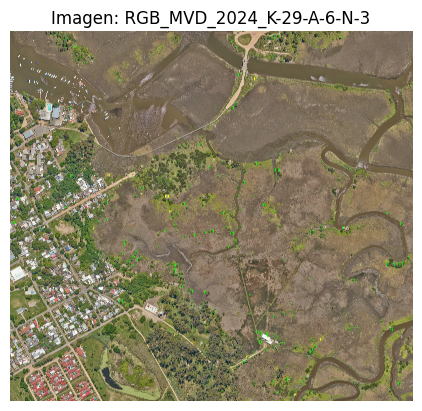

In [55]:
visualizador_coco_dataset.show_annotated_image_path(image_file_path, coco_annotations_path, image_name)

Mostramos los puntos:

In [56]:
predictions.as_pandas()

,x1,y1,x2,y2,confidence,class_id,class_name
0,2716.228210,432.652649,2887.730530,591.768860,0.929673,0,palmera-sana
1,2738.769653,250.266403,2920.644165,430.622864,0.917710,0,palmera-sana
2,2394.056335,437.067200,2469.161148,513.566345,0.866145,0,palmera-sana
3,2943.388550,462.342651,3086.463623,606.108887,0.907714,2,palmera-muerta
4,11152.835327,506.598267,11258.453430,611.167358,0.908244,1,palmera-infectada
...,...,...,...,...,...,...,...
273,15118.853699,18249.305237,15256.651428,18371.500549,0.874954,0,palmera-sana
274,15331.915283,18245.273193,15460.370117,18373.188721,0.798565,0,palmera-sana
275,19256.301697,18146.130554,19334.674377,18230.371643,0.564083,1,palmera-infectada
276,12096.000000,18596.885742,12172.037354,18681.439941,0.897602,1,palmera-infectada


#### Generar KML

In [57]:
jgw_data_path = DOWNLOAD_JGW_DATA_FOLDER / "jgw_data.json"
jgw_data = procesador_anotaciones_mongodb.load_jgw_file_from_mongodb(
    image_name=image_name, output_file_path=jgw_data_path
)
pprint(jgw_data)

2025-10-21 10:47:55.641 | SUCCESS  | modulo_utilidades.labeling.procesador_anotaciones_mongodb:load_jgw_file_from_mongodb:682 - Archivo JGW guardado en downloads\jgw_data\jgw_data.json.


{'x_origin': 559413.391802,
 'x_pixel_size': 0.05,
 'x_rotation': 0.0,
 'y_origin': 6150656.721772,
 'y_pixel_size': -0.05,
 'y_rotation': 0.0}


In [58]:
gdf_download_path = DOWNLOAD_GEOJSON_FOLDER / f"{image_name}_annotations.geojson"
gdf = procesador_geojson_kml.create_geojson_from_annotations(
    pic_name=image_name, coco_annotations=coco_annotations, jgw_data=jgw_data, output_file_path=gdf_download_path
)
gdf.head()

2025-10-21 10:47:55.786 | INFO     | modulo_utilidades.core.labeling.procesador_geojson_kml_core:create_geojson_from_annotations:150 - GeoJSON guardado en downloads\geojson_annotations\RGB_MVD_2024_K-29-A-6-N-3_annotations.geojson


,name,annotation_id,confidence,bbox_x,bbox_y,bbox_width,bbox_height,global_tl_x,global_tl_y,global_br_x,global_br_y,geometry
0,palmera-sana,1,0.93,2716.228210,432.652649,171.502319,159.116211,559549.203213,6.150635e+06,559557.778328,6.150627e+06,POINT (-56.34908 -34.78478)
1,palmera-sana,2,0.92,2738.769653,250.266403,181.874512,180.356461,559550.330285,6.150644e+06,559559.424010,6.150635e+06,POINT (-56.34906 -34.7847)
2,palmera-sana,3,0.87,2394.056335,437.067200,75.104813,76.499146,559533.094619,6.150635e+06,559536.849859,6.150631e+06,POINT (-56.34928 -34.78476)
3,palmera-muerta,4,0.91,2943.388550,462.342651,143.075073,143.766235,559560.561229,6.150634e+06,559567.714983,6.150626e+06,POINT (-56.34896 -34.78478)
4,palmera-infectada,5,0.91,11152.835327,506.598267,105.618103,104.569092,559971.033568,6.150631e+06,559976.314474,6.150626e+06,POINT (-56.34448 -34.78477)


In [59]:
kml_download_path = DOWNLOAD_KML_FOLDER / f"{image_name}.kml"
kml = procesador_geojson_kml.generate_kml_from_geojson(gdf, output_file_path=kml_download_path)

2025-10-21 10:47:55.899 | INFO     | modulo_utilidades.core.labeling.procesador_geojson_kml_core:generate_kml_from_geojson:234 - Archivo KML guardado en downloads\kml_annotations\RGB_MVD_2024_K-29-A-6-N-3.kml


In [60]:
# Test
kml_text = kml.to_string()
gdf_test = procesador_geojson_kml.convert_kml_to_geojson(kml_text)

2025-10-21 10:47:55.997 | SUCCESS  | modulo_utilidades.labeling.procesador_geojson_kml:convert_kml_to_geojson:123 - Conversión exitosa.
